In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

%matplotlib inline

(450, 338, 3)
(800, 1000, 3)


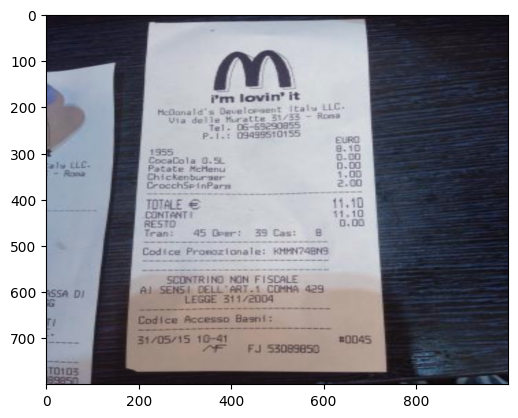

In [2]:
im_path="./bill.jpg"
img=cv2.imread(im_path)
print(img.shape)
img=cv2.resize(img,(1000,800))
print(img.shape)
#BGR FORMAT: BGR->RGB
plt.imshow(img)
plt.show()

In [3]:
#- remove the noise--blurr img
#- edge detection
#- contour extraction
#- best contour
#- show

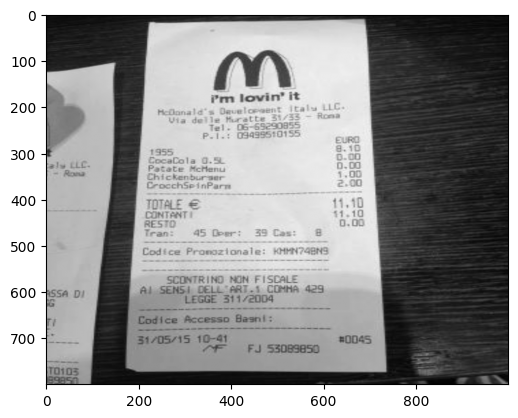

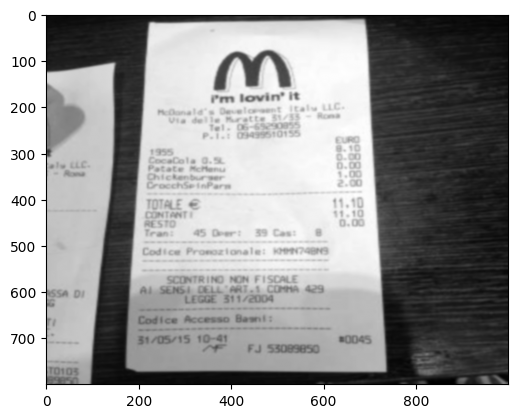

In [4]:
orig=img.copy()
gray=cv2.cvtColor(orig,cv2.COLOR_BGR2GRAY)
plt.imshow(gray,cmap="gray")
plt.show()
blurred=cv2.GaussianBlur(gray,(9,9),0)
plt.imshow(blurred,cmap="gray")
plt.show()

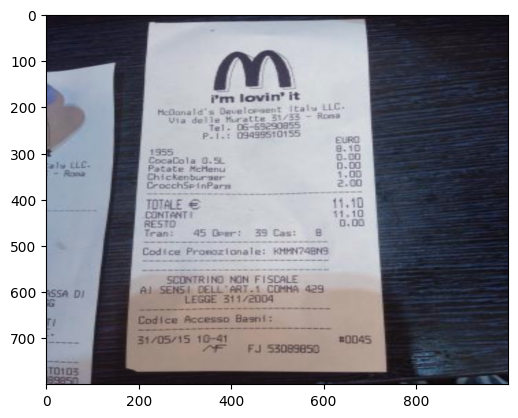

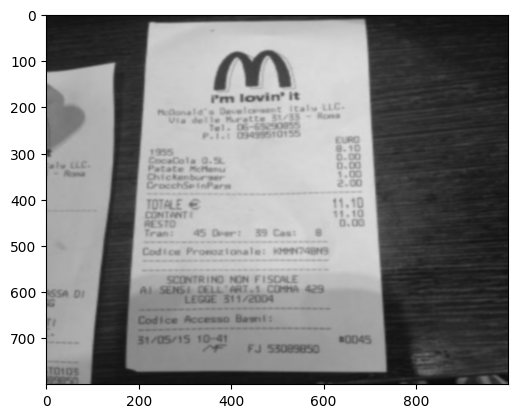

In [5]:
regen=cv2.cvtColor(blurred,cv2.COLOR_GRAY2BGR)
plt.imshow(orig)
plt.show()

plt.imshow(regen)
plt.show()

In [6]:
regen.shape

(800, 1000, 3)

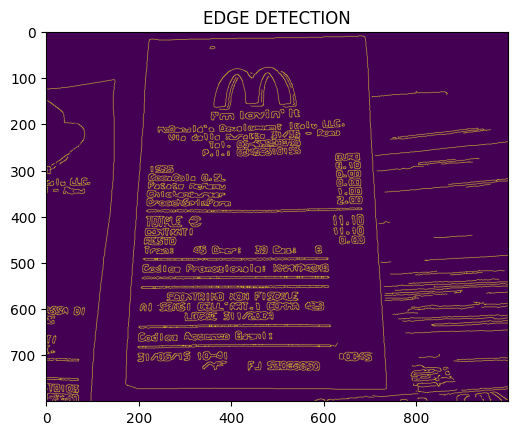

In [7]:
#edge detection
edge=cv2.Canny(blurred,0,50)
orig_edge=edge.copy()
plt.title("EDGE DETECTION")
plt.imshow(orig_edge)
plt.show()

In [8]:
#contour extraction
contours,_=cv2.findContours(edge, cv2.RETR_LIST,cv2.CHAIN_APPROX_NONE)
print(len(contours))

contours=sorted(contours, reverse=True,key=cv2.contourArea)

921


In [9]:
#select best contour

In [10]:
for i in contours:
    p=cv2.arcLength(i,True)
    approx=cv2.approxPolyDP(i,0.01*p,True)

    if len(approx)==4:
        target=approx
        break
print(target.shape)

(4, 1, 2)


In [11]:
# reorder target contours

import numpy as np

def reorder(h):
    h = h.reshape((4, 2))

    hnew = np.zeros((4, 2), dtype=np.float32)

    add = h.sum(axis=1)
    hnew[0] = h[np.argmin(add)]  # top-left
    hnew[2] = h[np.argmax(add)]  # bottom-right

    diff = np.diff(h, axis=1)
    hnew[1] = h[np.argmin(diff)]  # top-right
    hnew[3] = h[np.argmax(diff)]  # bottom-left

    return hnew

In [12]:
reorder= reorder(target)
print("****************")
print(reorder)

****************
[[223.  19.]
 [690.  12.]
 [736. 773.]
 [174. 765.]]


In [13]:
#show

ip=reorder
op=np.float32([[0,0],[600,0],[600,600],[0,600]])
M=cv2.getPerspectiveTransform(ip,op)
ans=cv2.warpPerspective(orig,M,(600,600))

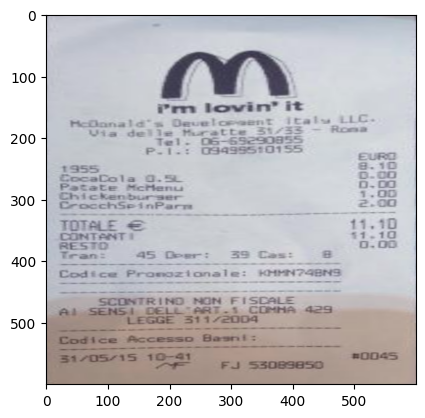

In [14]:
plt.imshow(ans)
plt.show()

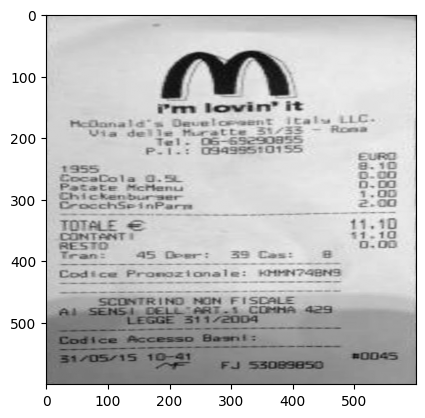

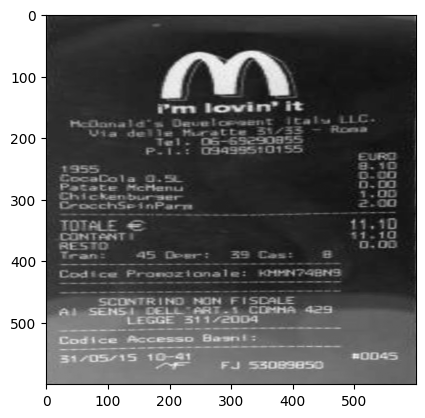

In [15]:
res=cv2.cvtColor(ans,cv2.COLOR_BGR2GRAY)

plt.imshow(res,cmap="gray")
plt.show()
plt.imshow(res,cmap="binary")
plt.show()



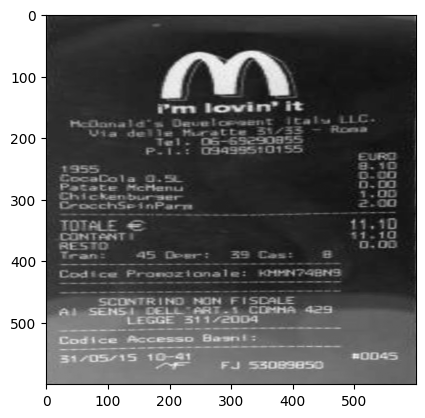

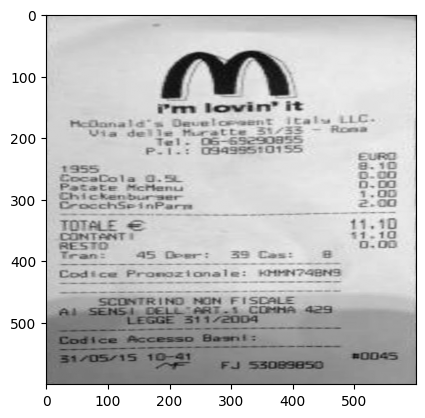

In [16]:
denoise=cv2.GaussianBlur(res,(1,1),0)

plt.imshow(denoise,cmap="binary")
plt.show()
plt.imshow(denoise,cmap="gray")
plt.show()